In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, classification_report, confusion_matrix, accuracy_score, average_precision_score
from sklearn.metrics import PrecisionRecallDisplay

## Load Data

In [26]:
df2 = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df2.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


### Train-test split

In [27]:
X = df2.drop(columns=['malnurished'])
y = df2['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

# K-nearest Neighborhood

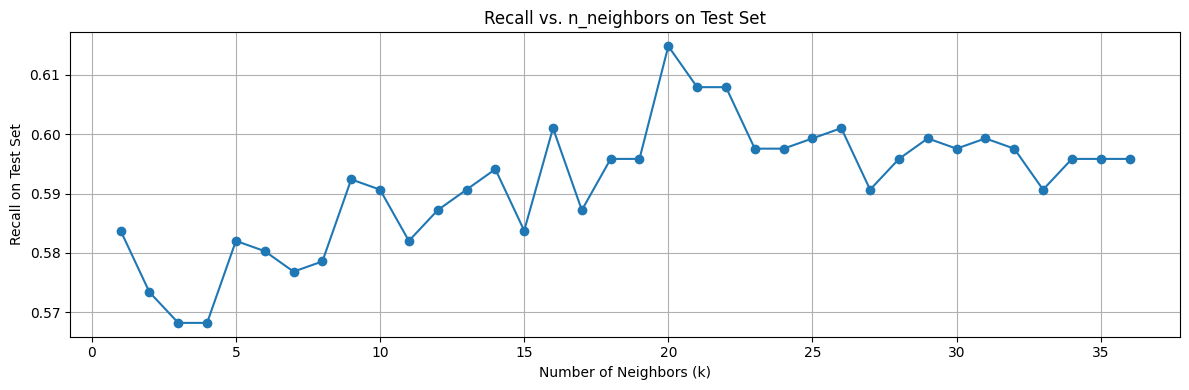

In [32]:
recalls = []

for k in range(1, 37):
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    recalls.append(recall_score(y_test, y_pred))

plt.figure(figsize=(12, 4))
plt.plot(range(1, 37), recalls, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Recall on Test Set")
plt.title("Recall vs. n_neighbors on Test Set")
plt.grid()
plt.tight_layout()
plt.show()

In [37]:
knn = KNeighborsClassifier(n_neighbors=20, weights='distance')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(f'Classification Report: \n{classification_report(y_test, y_pred)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.69      0.71      0.70       707
           1       0.64      0.61      0.63       579

    accuracy                           0.67      1286
   macro avg       0.67      0.66      0.66      1286
weighted avg       0.67      0.67      0.67      1286




AttributeError: Line2D.set() got an unexpected keyword argument 'despine'

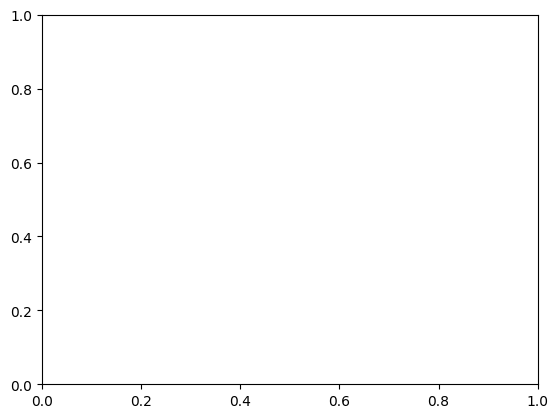

In [ ]:
display = PrecisionRecallDisplay.from_estimator(
    knn,                  # trained model
    X_test,               # Test features
    y_test,               # True labels
    name="KNN",
    plot_chance_level=True,
    despine=True
)
display.ax_.set_title("2-class Precision-Recall curve")
plt.show()

# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
params = {'n_neighbors':range(1, 36), 
          'weights':['uniform', 'distance'], 
          'p':[1,2]}

knn = KNeighborsClassifier()
cv = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)
knn_grid_cv = GridSearchCV(knn, 
                           param_grid=params, 
                           scoring='recall', 
                           cv=cv
                           ) 
knn_grid_cv.fit(X_train, y_train)

print("Best CV Recall Score:", knn_grid_cv.best_score_)
print("Best Estimator:", knn_grid_cv.best_estimator_)

Best CV Recall Score: 0.5540426587301587
Best Estimator: KNeighborsClassifier(n_neighbors=4, weights='distance')


In [ ]:
y_pred_tunned = knn_grid_cv.predict(X_test)
print(f'Classification Report: \n{classification_report(y_test, y_pred_tunned)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.67      0.65      0.66       397
           1       0.58      0.60      0.59       320

    accuracy                           0.63       717
   macro avg       0.63      0.63      0.63       717
weighted avg       0.63      0.63      0.63       717




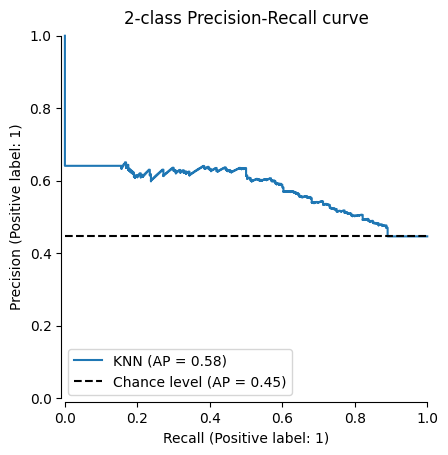

In [ ]:
display = PrecisionRecallDisplay.from_estimator(
    knn_grid_cv,   # trained model
    X_test,        # Test features
    y_test,        # True labels
    name="KNN",
    plot_chance_level=True,
    despine=True
)
display.ax_.set_title("2-class Precision-Recall curve")
plt.show()